# Optimal Drilling Point Selection Under Uncertainty


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Introduction and data import

You work for a mining company specializing in the extraction of materials for the electric batteries of the future. You are in charge of deciding **where to install a drilling point** on an island containing ore in the subsoil.

The island is square, and the geographical coordinates on the island are represented by a pair $u = (u_1, u_2) \in [0,1]^2$. The yield of a drilling operation at point $u$ is denoted $Y_u$. It depends on the quantity of ore in the subsoil at point $u$, denoted $\bar{g}(u)$ and unknown, as well as on geological parameters $X = (X_0, \ldots, X_9)$ that are also uncertain.

These parameters are the following:

- $X_0$: operational variability of the drilling process;
- $X_1$: depth of the mineralized layer;
- $X_2$: crystal concentration;
- $X_3$: rock permeability;
- $X_4$: mineral density of the rock;
- $X_5$: soil moisture;
- $X_6$: level of micro-fracturing of the rock;
- $X_7$: subsurface temperature;
- $X_8$: secondary chemical composition of the rock;
- $X_9$: intensity of underground hydrological flows.

They are modeled as **independent random variables**. Furthermore, the soil is assumed to be statistically homogeneous across the island, so that the joint distribution of $X = (X_0, \ldots, X_9)$ does not depend on $u$. The yield $Y_u$ is therefore modeled as a **random variable of the form $Y_u = g(u, X)$**, with an unknown function $g$ that depends on $u$ through $\bar{g}(u)$.

The company is particularly sensitive to **risk**: it wishes to guarantee a minimum production level even under unfavorable conditions (and thereby avoid going bankrupt). For a given $\alpha \in (0,1)$, the objective is therefore to find a drilling point $u_*$ that maximizes the **quantile** of order $\alpha$ of $Y_u$: if $\alpha = 0.2$, this means that we maximize the guaranteed production in the **$20\%$ most unfavorable scenarios**.

You must therefore solve the optimization problem

$$\max_{u \in [0,1]^2} q_{0.2}(Y_u).$$

To this end, you have access to a dataset consisting of a series of measurements $(X^{(k)}, u^{(k)}, Y^{(k)})_{1 \leq k \leq N}$ previously collected by your company.

In [4]:
XuY_sample = pd.read_csv("https://drive.google.com/uc?export=download&id=1JLORduJ91Dxol6oY0JmIodMe1xLivk14")

# Quick summary of dataset
print("Sample size:", XuY_sample.shape[0])
XuY_sample.head()

,$X_0$,$X_1$,$X_2$,$X_3$,$X_4$,$X_5$,$X_6$,$X_7$,$X_8$,$X_9$,$u_1$,$u_2$,$Y$
0,17.905841,0.910861,3.949710,3.069692,0.948293,-0.270227,10.847923,45.255552,0.268704,1.000277,0.771321,0.020752,-0.500804
1,4.394330,0.883915,2.465288,0.892781,0.857141,0.372025,15.094336,15.874921,0.449678,0.927614,0.633648,0.748804,0.713007
2,7.974534,0.924758,2.551661,0.345361,0.951140,-0.285348,13.008709,20.208888,0.264426,0.720983,0.498507,0.224797,0.107336
3,29.261512,0.986942,2.524082,-2.810223,0.886743,0.419425,8.451705,24.237377,0.098390,0.996779,0.198063,0.760531,0.237568
4,19.920270,0.935119,3.942926,-0.256595,0.883896,-0.006473,1.973935,13.583436,0.034439,0.905410,0.169111,0.088340,0.180804


We may have a first look at this data: on this map of the island, each dot is a measurement, and the color is the measured valued of $Y$.

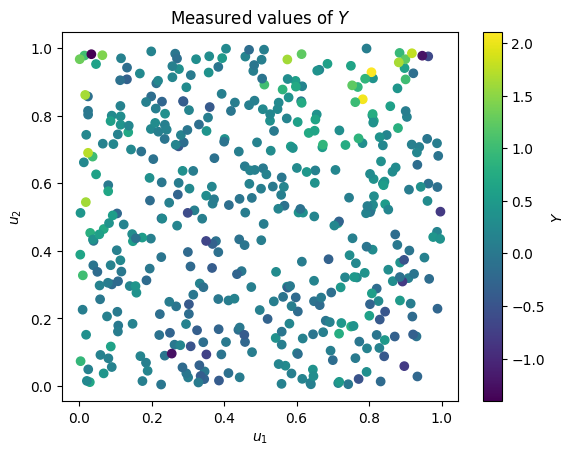

In [5]:
plt.figure()

plt.scatter(XuY_sample['$u_1$'], XuY_sample['$u_2$'], c=XuY_sample['$Y$'])

plt.xlabel("$u_1$")
plt.ylabel("$u_2$")
plt.title("Measured values of $Y$")

plt.colorbar(label="$Y$")
plt.show()

Since you do not know the function $g$, it is difficult to derive directly an estimate of the quantile of $Y_u$ at each point $u$ from the dataset.

In this lab session, we will use the observed data to:

1. Build a **probabilistic model** of the vector $X$, i.e., estimate the marginal distributions of the variables $X_0, \ldots, X_9$;
2. Build a **surrogate model** of $g$, i.e., a function $\tilde{g}$ that best approximates the true function $g$.

With these two ingredients, it will become possible to generate, at a given point $u$, i.i.d. realizations of $\tilde{Y}_u = \tilde{g}(u, X)$ in order to estimate the quantile of this random variable using the Monte Carlo method, and then to find the point $\tilde{u}_*$ that maximizes this quantile. If the surrogate model $\tilde{g}$ is a good approximation of the true function $g$, the point $\tilde{u}_*$ should be close to the true maximum-yield point $u_*$: the treasure!

The lab session is divided into 4 steps:

- **Step 1:** Construction of the probabilistic model for $X$
- **Step 2:** Dimension reduction — this step is necessary because building a surrogate model in dimension 12 with so few data points is unrealistic
- **Step 3:** Construction of the surrogate model
- **Step 4:** Optimization

## Step 1: probabilistic model for $X$

The goal of this step is to identify the marginal distribution of each variable $X_i$, using the measured data. We will therefore only need the DataFrame `X_sample`.

In [6]:
X_sample = XuY_sample.drop(columns=['$u_1$', '$u_2$', '$Y$'])
X_sample.head()

,$X_0$,$X_1$,$X_2$,$X_3$,$X_4$,$X_5$,$X_6$,$X_7$,$X_8$,$X_9$
0,17.905841,0.910861,3.949710,3.069692,0.948293,-0.270227,10.847923,45.255552,0.268704,1.000277
1,4.394330,0.883915,2.465288,0.892781,0.857141,0.372025,15.094336,15.874921,0.449678,0.927614
2,7.974534,0.924758,2.551661,0.345361,0.951140,-0.285348,13.008709,20.208888,0.264426,0.720983
3,29.261512,0.986942,2.524082,-2.810223,0.886743,0.419425,8.451705,24.237377,0.098390,0.996779
4,19.920270,0.935119,3.942926,-0.256595,0.883896,-0.006473,1.973935,13.583436,0.034439,0.905410


We first look at the correlations between these variables in order to make sure that the independence assumption is justified.

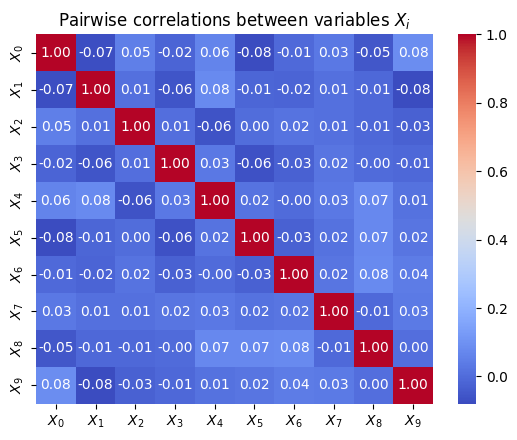

In [8]:
import seaborn as sns

# Pairwise correlations
plt.figure()
sns.heatmap(X_sample.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Pairwise correlations between variables $X_i$")
plt.show()

We may now focus on the estimation of marginal distributions.

In [9]:
# From now on it is easier to convert the DataFrame X_sample into an np.array
X_sample = X_sample.to_numpy()
N_sample = X_sample.shape[0]
print("N_sample:", N_sample)

N_sample: 443


We plot the histograms of each variable $X_i$.

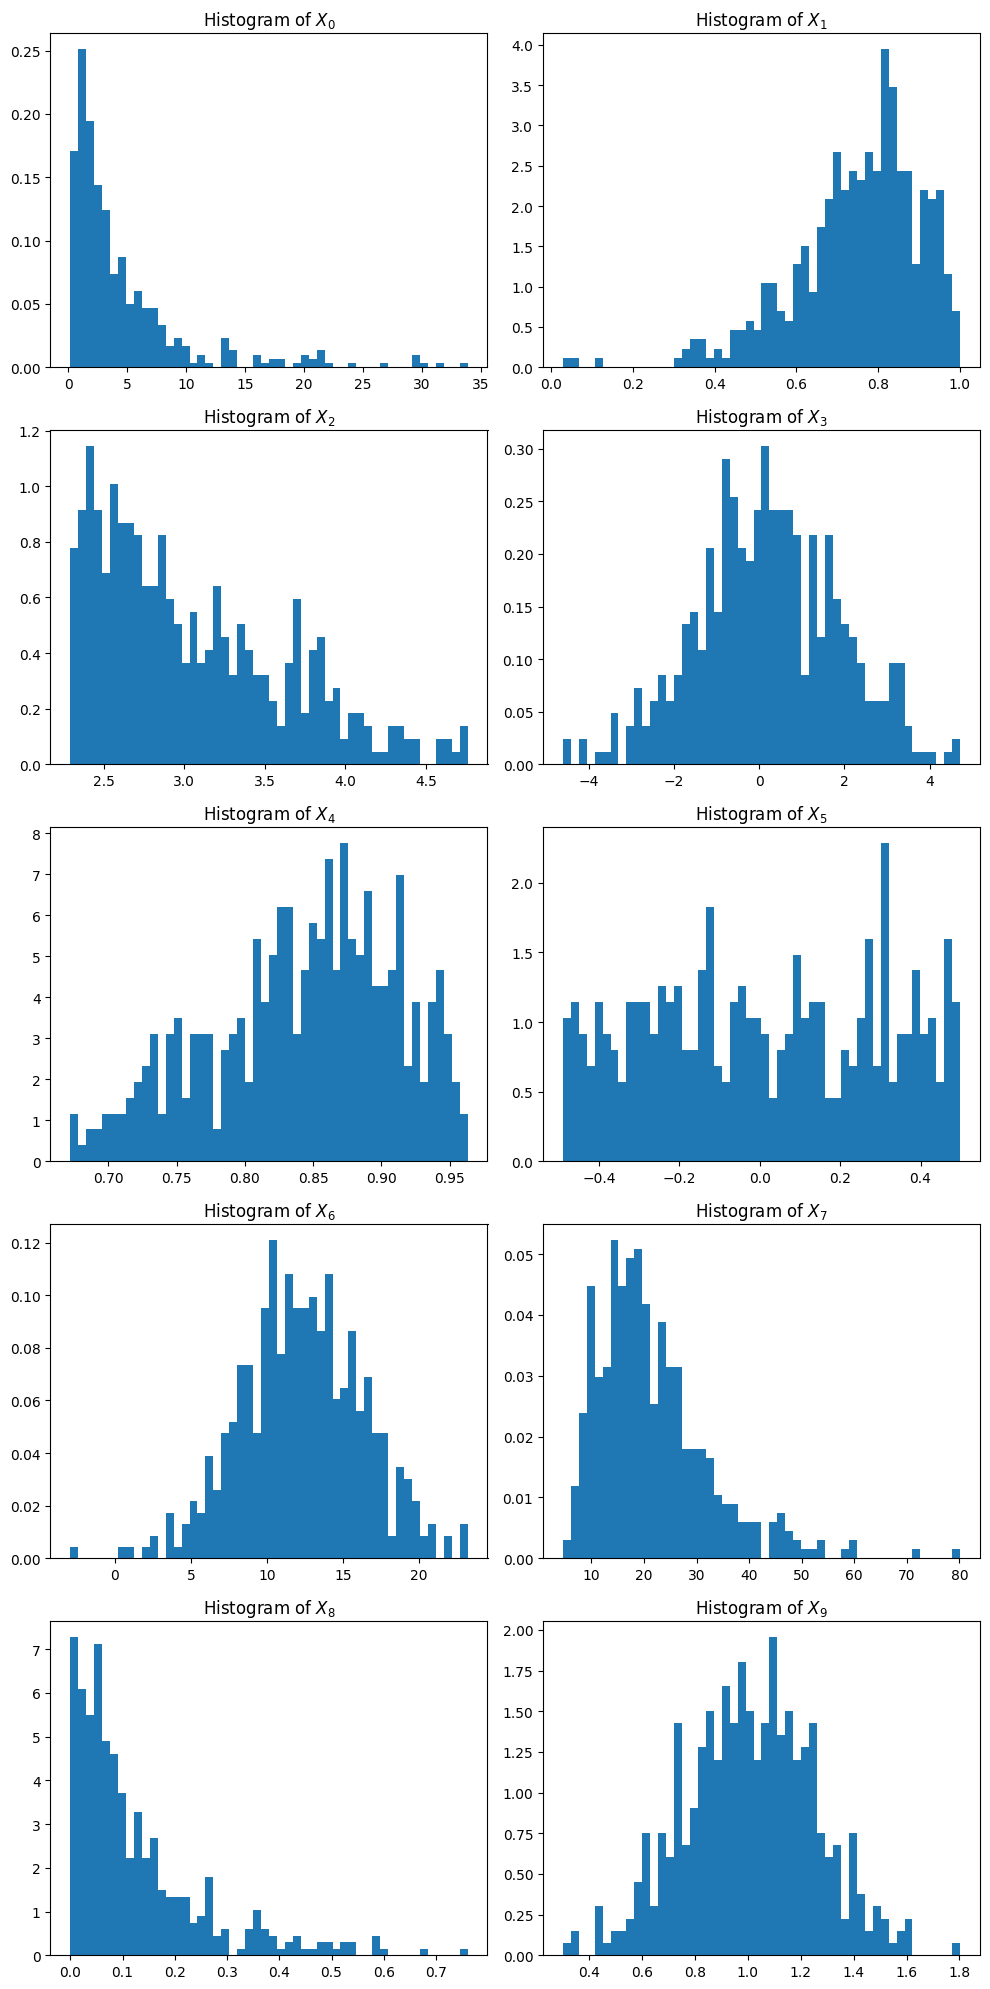

In [18]:
fig, ax = plt.subplots(5, 2, figsize=(10, 20))

for i, axi in enumerate(ax.ravel()):
    axi.hist(X_sample[:, i], bins=50, density=True)
    axi.set_title(rf"Histogram of $X_{i}$")

plt.tight_layout()
plt.show()

The goal of Step 1 is to fill the list `estim_marginal_distributions`, which must contain $10$ elements, each of which being a *frozen distribution* from the library `scipy.stats`. A frozen distribution is the definition of a probability distribution with parameters. You should take a look at the dedicated [Notebook on Scipy.stats distributions](https://colab.research.google.com/drive/1wJyG5y4DX-nqoZd596UrJG5FnwcmTIpR?usp=sharing) to learn more about it.

**QUESTION:** complete the list `estim_marginal_distributions` for it to contain $10$ frozen distributions, with parameters estimated from the dataset. You may restrict yourself to the following `scipy.stats` distributions: `uniform`, `beta`, `triang`, `expon`, `norm`, `lognorm`.

In [22]:
# List of distributions with which we shall work
from scipy.stats import uniform, beta, triang, expon, norm, lognorm

In [87]:
estim_marginal_distributions = []

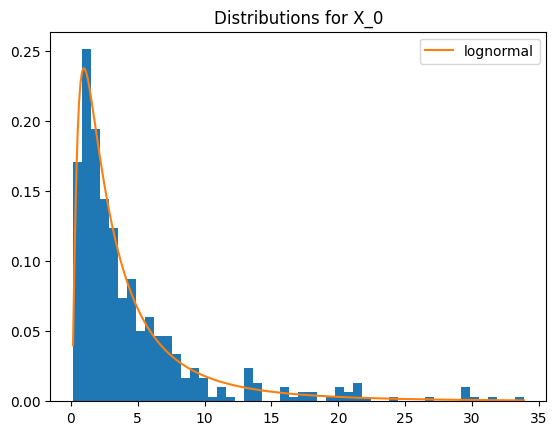

In [88]:
# Feature X_0

data = X_sample[:, 0]
plt.hist(data, bins=50, density=True)
x = np.linspace(data.min(), data.max(), 300)

# Lognormal
s_l, loc_l, scale_l = lognorm.fit(data)
plt.plot(x, lognorm.pdf(x, s=s_l, loc=loc_l, scale=scale_l), label="lognormal")


plt.title("Distributions for X_0")
plt.legend()
plt.show()

estim_marginal_distributions.append(lognorm(s=s_l, loc=loc_l, scale=scale_l))

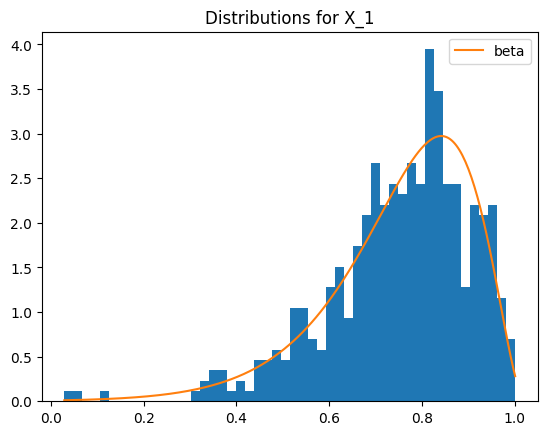

In [89]:
# Feature X_1

data = X_sample[:, 1]
plt.hist(data, bins=50, density=True)
x = np.linspace(data.min(), data.max(), 300)


# Beta
a_b, b_b, loc_b, scale_b = beta.fit(data)
plt.plot(x, beta.pdf(x, a=a_b, b=b_b, loc=loc_b, scale=scale_b), label="beta")


plt.title("Distributions for X_1")
plt.legend()
plt.show()

estim_marginal_distributions.append(beta(a=a_b, b=b_b, loc=loc_b, scale=scale_b))

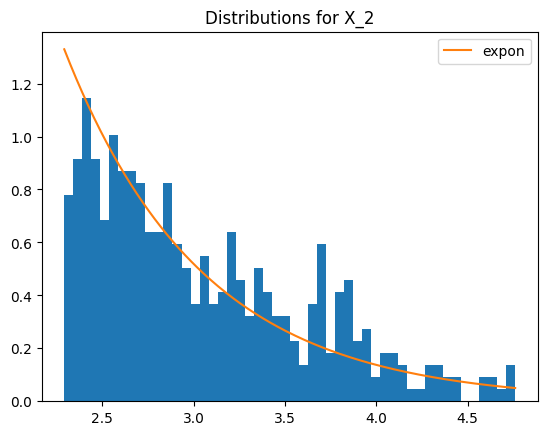

In [90]:
# Feature X_2

data = X_sample[:, 2]
plt.hist(data, bins=50, density=True)
x = np.linspace(data.min(), data.max(), 300)


# Exponential
loc_e, scale_e = expon.fit(data)
plt.plot(x, expon.pdf(x, loc=loc_e, scale=scale_e), label="expon")


plt.title("Distributions for X_2")
plt.legend()
plt.show()

estim_marginal_distributions.append(expon(loc=loc_e, scale=scale_e))


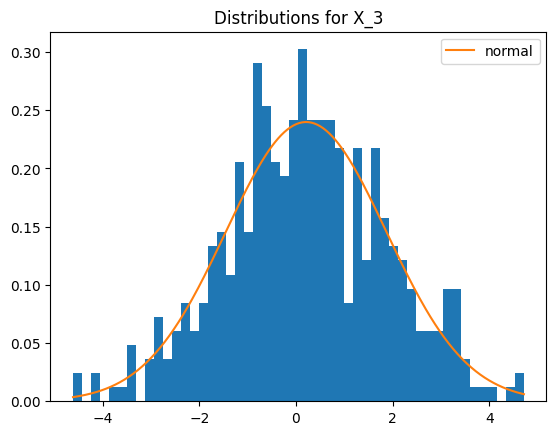

In [91]:
# Feature X_3

data = X_sample[:, 3]
plt.hist(data, bins=50, density=True)
x = np.linspace(data.min(), data.max(), 300)

# Normal
loc_n, scale_n = norm.fit(data)
plt.plot(x, norm.pdf(x, loc=loc_n, scale=scale_n), label="normal")

plt.title("Distributions for X_3")
plt.legend()
plt.show()

estim_marginal_distributions.append(norm(loc=loc_n, scale=scale_n))

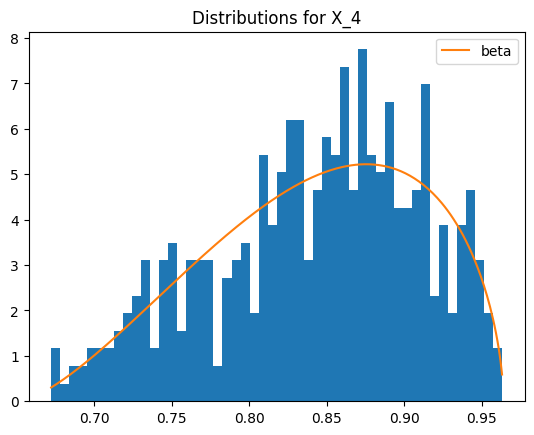

In [92]:
# Feature X_4

data = X_sample[:, 4]
plt.hist(data, bins=50, density=True)
x = np.linspace(data.min(), data.max(), 300)


# Beta
a_b, b_b, loc_b, scale_b = beta.fit(data)
plt.plot(x, beta.pdf(x, a=a_b, b=b_b, loc=loc_b, scale=scale_b), label="beta")


plt.title("Distributions for X_4")
plt.legend()
plt.show()

estim_marginal_distributions.append(beta(a=a_b, b=b_b, loc=loc_b, scale=scale_b))

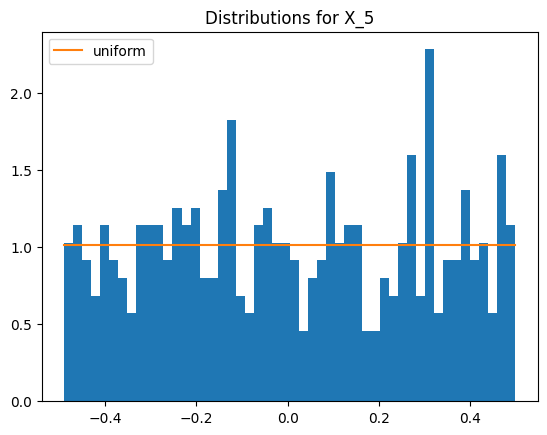

In [93]:
# Feature X_5

data = X_sample[:, 5]
plt.hist(data, bins=50, density=True)
x = np.linspace(data.min(), data.max(), 300)

# Uniform
loc_u, scale_u = uniform.fit(data)
plt.plot(x, uniform.pdf(x, loc=loc_u, scale=scale_u), label="uniform")

plt.title("Distributions for X_5")
plt.legend()
plt.show()

estim_marginal_distributions.append(uniform(loc=loc_u, scale=scale_u))


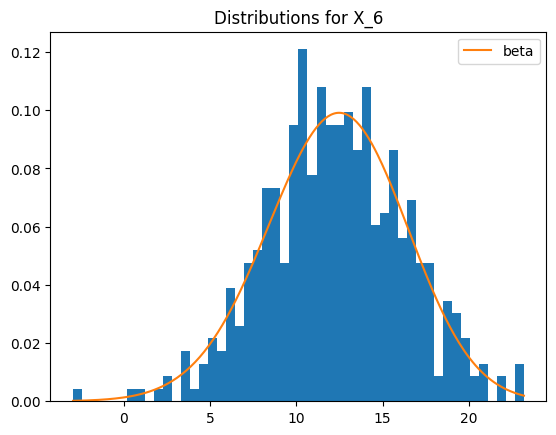

In [94]:
# Feature X_6

data = X_sample[:, 6]

plt.hist(data, bins=50, density=True)
x = np.linspace(data.min(), data.max(), 300)

# Beta
a_b, b_b, loc_b, scale_b = beta.fit(data)
plt.plot(x, beta.pdf(x, a=a_b, b=b_b, loc=loc_b, scale=scale_b), label="beta")




plt.title("Distributions for X_6")
plt.legend()
plt.show()

estim_marginal_distributions.append(beta(a=a_b, b=b_b, loc=loc_b, scale=scale_b))


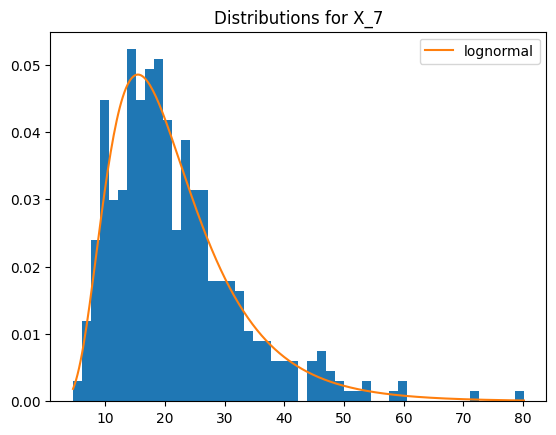

In [95]:
# Feature X_7

plt.hist(X_sample[:, 7], bins=50, density=True)
x = np.linspace(X_sample[:, 7].min(), X_sample[:, 7].max(), 300)

# Lognormal
s_l, loc_l, scale_l = lognorm.fit(X_sample[:, 7])
plt.plot(x, lognorm.pdf(x, s=s_l, loc=loc_l, scale=scale_l), label="lognormal")


plt.title("Distributions for X_7")
plt.legend()
plt.show()

estim_marginal_distributions.append(lognorm(s=s_l, loc=loc_l, scale=scale_l))


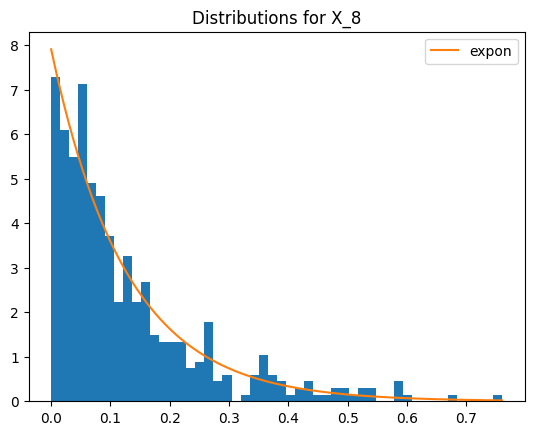

In [96]:
# Feature X_8

plt.hist(X_sample[:, 8], bins=50, density=True)
x = np.linspace(X_sample[:, 8].min(), X_sample[:, 8].max(), 300)

# Exponential
loc_e, scale_e = expon.fit(X_sample[:, 8])
plt.plot(x, expon.pdf(x, loc=loc_e, scale=scale_e), label="expon")

plt.title("Distributions for X_8")
plt.legend()
plt.show()

estim_marginal_distributions.append(expon(loc=loc_e, scale=scale_e))


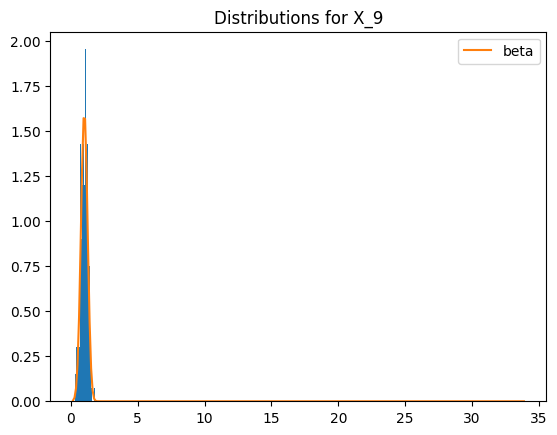

In [97]:
# Feature X_9

plt.hist(X_sample[:, 9], bins=50, density=True)
x = np.linspace(X_sample[:, i].min(), X_sample[:, i].max(), 300)

# Beta
a_b, b_b, loc_b, scale_b = beta.fit(X_sample[:, 9])
plt.plot(x, beta.pdf(x, a=a_b, b=b_b, loc=loc_b, scale=scale_b), label="beta")

plt.title("Distributions for X_9")
plt.legend()
plt.show()

estim_marginal_distributions.append(beta(a=a_b, b=b_b, loc=loc_b, scale=scale_b))


In [98]:
print(estim_marginal_distributions)

[<scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x122e94690>, <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x122e0d940>, <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x122e0e9e0>, <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x122096570>, <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x122e53ce0>, <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x122e539b0>, <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x12207de50>, <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x122eb8450>, <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x122e7a030>, <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x122e79b80>]


To visualize the result of the estimation, we superpose the histogram of the data with the density (pdf) of the estimated distributions.

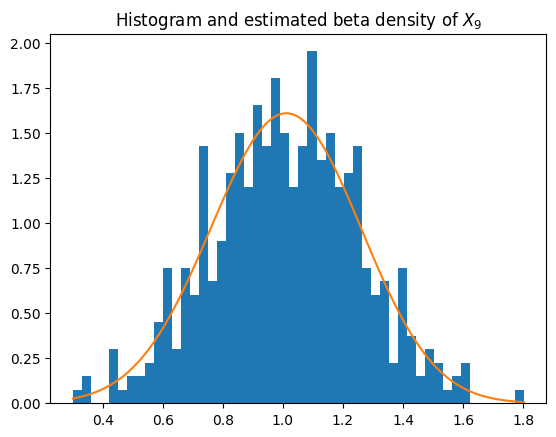

In [99]:
for i in range(10):
  # Histogram
  plt.hist(X_sample[:,i], bins=50, density=True)

  # Density
  x_min = np.min(X_sample[:,i])
  x_max = np.max(X_sample[:,i])
  x_plot = np.linspace(x_min, x_max, 100)
  plt.plot(x_plot, estim_marginal_distributions[i].pdf(x_plot))

  # Show
  plt.title(f"Histogram and estimated {estim_marginal_distributions[i].dist.name} density of $X_{i}$")
  plt.show()

To get a more quantitative estimation, we may also apply a [one-sample Kolmogorov test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ks_1samp.html#scipy.stats.ks_1samp) between the dataset and the estimated distrbution: the larger the $p$-value, the better the fit.

In [100]:
from scipy.stats import ks_1samp

for i in range(10):
  test = ks_1samp(X_sample[:,i], estim_marginal_distributions[i].cdf)
  distribution_type = estim_marginal_distributions[i].dist.name
  print(f"p-value for {distribution_type} model for X_{i}:", test.pvalue)

p-value for lognorm model for X_0: 0.9954026127803208
p-value for beta model for X_1: 0.7278134337005653
p-value for expon model for X_2: 0.051077767811705144
p-value for norm model for X_3: 0.942002082873925
p-value for beta model for X_4: 0.4303047784492229
p-value for uniform model for X_5: 0.6526761016753734
p-value for beta model for X_6: 0.9809335460969558
p-value for lognorm model for X_7: 0.8899281857917046
p-value for expon model for X_8: 0.5763539372424069
p-value for beta model for X_9: 0.986043682309847


**If you are happy with your estimated marginal densities, you may now pass to Step 2,** where you will use the function `sample_from_X()` to generate realisations of $X$ under the distributions contained in `estim_marginal_distributions`.

In [101]:
def sample_from_X(size=1):
  # Returns a (size,10) array whose rows are iid samples from the estimated marginal distributions
  X = np.zeros((size,10))
  for i in range(10):
    X[:,i] = estim_marginal_distributions[i].rvs(size=size)

  return X

## Step 2: dimension reduction by sensitivity analysis

The goal of this Step is to determine which of the variables $X_0, \ldots, X_9$ are most influential in the variation of $Y_u$. The magnitude of the relative influence of each $X_i$ on $Y_u$ may vary with $u$, and using just the dataset it is difficult to estimate this magnitude, because for a given value of $u$ there are too few observations close to $u$.

Fortunately, your company has already set up a drilling point on the island, at the location $u^0 = (.5,.5)$ (the center of the square). With repeated measurements of $Y_{u^0}$, the UQ engineer who used to work in your place has already devised a surrogate model `g_loc(X)` (`loc` stands for *local*), which takes in input a two-dimensional array $X$, with dimension `(N,10)`, and returns a one-dimensional vector $Y$, of length $N$, which contains the values of $g(u^0,X^{(j)})$ for $j$ ranging from $0$ to $N-1$ (and $X^{(j)}$ referring to the $j$-th row of $X$).

Believe it or not, the code of the function `g_loc` is contained in the following cell.

In [106]:
import zlib as _z,base64 as _b
exec(_z.decompress(_b.b64decode('eNptk01vozAQhu/8Co6GOl7b5KOk4lKp2ktV9dBGrSI0coiTRQGCDGzJ/vodG0hbqUhge/y8M2PPkJf12bR+1ZX1xVeND5WXD6ZaVXs0WFvtHcy59Jssry+saVXb+CPUVfnhbEpHvdKdbpWb3tPW5Ko6usUL1X19rtz8gVYT/kSL8/G6evwWotZZroopiP6rCij0UVd7ox397EGZbOGRNIlgPEJPWcIZbTJV6ESyWAQU7olKYhYt6A4tcuWYGYvESAkWyYB6DmPxraPiwRPi8UhFjFtfT8TamYiv4qWw4heC1pV0KrZcjLssilDzSoaI80nE4thqBl9CMiHHjTnjtyiwp7G0cyanTRGz5crqHpyOT85EdM1LTCdnchGk3l4ffOiPBN6CtefjAyYpVLnbKx/yNZq3awp5OoNyiwMrtapIEPwal027J4GTGd12psKOYNm56MoKsPLZiWzBEBvbkKX7xkEaDDGPikBH4fcUVlHYJdBhOJ5SN4r0DjYJPLFsfyAI4opT2Ah8ZQKbkdw4chhlOvjqKVwSGYKaIby7g4/rkU4U/q3hmbjJ18wJEyEm3+QVmdtJnaM8mEzLybQLbqAP4YNEGCIICQbZ8JkYPNlnBpcwlJaYU+hHQiCB1hu0yk8drhFAPW590Tvf/SdzsYxAJvCgSTAPZYy64M1iCU5jCfC3wrP5eeUb/JE0EdzeM2BrcO7ONWokvaURFZwKuqAruqQxnadYzcbV5AjYIF86oeM2nNG1Vi3ZbtmCskWKV/3Gmj+q1lu8ftXnTcKxNO/JUFGs0NBNw5X8kNjasu83kNn0w6HBTum3Jnr3/gO7JkmT')))

To test it, we plot the distribution of `g_loc(X)` with the estimated distributions for the components of $X$.

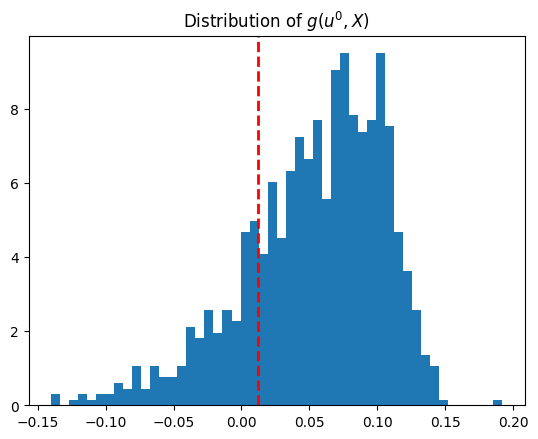

In [107]:
# Test of g_loc
N_test = 1000

X_test = sample_from_X(size=N_test)
Y_test = g_loc(X_test)

plt.hist(Y_test, bins=50, density=True)
plt.title("Distribution of $g(u^0,X)$")

# We may also add the quantile of order alpha = 0.2
alpha = 0.2
q_alpha = np.quantile(Y_test, alpha)
plt.axvline(x=q_alpha, linestyle='--', linewidth=2, color="red")

plt.show()

To evaluate the influence of each $X_i$ on the random variable $Y_{u^0}$, we will compute [**Sobol' indices**](https://en.wikipedia.org/wiki/Variance-based_sensitivity_analysis). Writing $Y = Y_{u^0} = g(u^0,X)$ for short, the (first-order) Sobol' index associated with the input variable $X_i$ is defined by
$$S_i = \frac{\mathrm{Var}\ (\mathbb{E}[Y|X_i])}{\mathrm{Var}(Y)}.$$
It is an easy exercise to check that $S_i \in [0,1]$. Moreover, if $Y$ does not depend on $X_i$ then $S_i=0$, while if $Y$ depends only on $X_i$, and not on the other variables, then $S_i=1$. Loosely speaking, $S_i$ must therefore be interpreted as the proportion of variance of $Y$ which may be attributed to $X_i$. The larger $S_i$, the more *$Y$ depends on $X_i$*.

To compute the Sobol indices, we will use the *pick-freeze method*. It relies on the following formula: let $X = (X_0, \ldots, X_{d-1})$ and $X' = (X'_0, \ldots, X'_{d-1})$ be two independent vectors with the same marginal distributions (in our setting $d=10$). For $i \in \{0, \ldots, d-1\}$, define the vector $X_{[i]} = (X_{[i],0}, \ldots, X_{[i],d-1})$ by
$$X_{[i],j} = \begin{cases}
  X_j & \text{if $j=i$,}\\
  X'_j & \text{if $j \not=i$.}
\end{cases}$$
In other words, $X_{[i],j}$ is $X_j$ at $j=i$ and $X'_j$ everywhere else. Then it turns out that
$$S_i = \frac{\mathrm{Cov}(Y,Y_{[i]})}{\mathrm{Var}(Y)},$$
where $Y_{[i]} = g(u_0, X_{[i]})$.
Both the numerator and denominator may be estimated by their empirical versions, which requires to:
* simulate two independent samples $\{X^{(k)}\}_{1 \leq k \leq N}$ and $\{X'^{(k)}\}_{1 \leq k \leq N}$ using `sample_from_X`;
* compute the values of $Y^{(k)} = g(u^0, X^{(k)})$ using `g_loc` and estimate $\mathrm{Var}(Y)$ by the empirical variance of the sample $\{Y^{(k)}\}_{1 \leq k \leq N}$;
* for each $i \in \{0, \ldots, d-1\}$, form the sample $\{X^{(k)}_{[i]}\}_{1 \leq k \leq N}$ from $\{X^{(k)}\}_{1 \leq k \leq N}$ and $\{X'^{(k)}\}_{1 \leq k \leq N}$, compute the values of $Y^{(k)}_{[i]} = g(u^0, X^{(k)}_{[i]})$ using `g_loc` and estimate $\mathrm{Cov}(Y,Y_{[i]})$ by the empirical variance of the samples $\{Y^{(k)}\}_{1 \leq k \leq N}$ and $\{Y^{(k)}_{[i]}\}_{1 \leq k \leq N}$.

**QUESTION:** Implement this estimation procedure and complete the vector `Sobol_indices` with the estimated values of $S_0, \ldots, S_9$.

In [122]:
Sobol_indices = np.zeros(10)

N = 1000

# Generate samples
X = sample_from_X(size=N)
X_prime = sample_from_X(size=N)

# Evaluate model
Y = g_loc(X)

# Use unbiased variance (recommended)
var_Y = np.var(Y, ddof=1)

for i in range(10):
    # Construct X_[i]
    X_i = X_prime.copy()
    X_i[:, i] = X[:, i]

    # Evaluate Y_[i]
    Y_i = g_loc(X_i)

    # Compute covariance Cov(Y, Y_i)
    cov_Y_Yi = np.mean((Y - np.mean(Y)) * (Y_i - np.mean(Y_i)))

    # Sobol index
    Sobol_indices[i] = cov_Y_Yi / var_Y

print(Sobol_indices)

[0.01235616 0.04283095 0.01417866 0.31982698 0.00980807 0.02742291
 0.2720713  0.0212483  0.01895404 0.17194807]


To visualize the results we observe the values of the estimated Sobol indices.

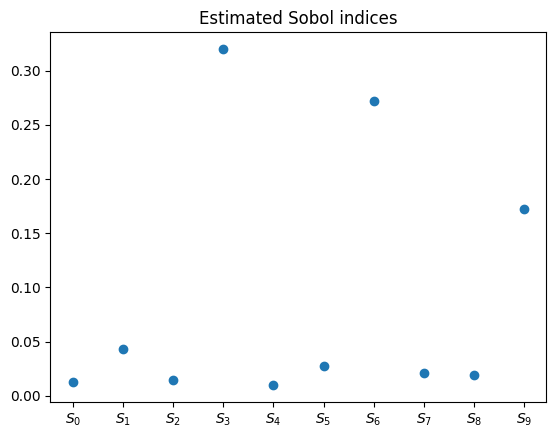

In [123]:
plt.plot(Sobol_indices, 'o')
plt.xticks(range(10), [f'$S_{i}$' for i in range(10)])
plt.title("Estimated Sobol indices")
plt.show()

In the next Step, we will reduce the dimension of the input space by looking for a surrogate model to the function $g(u,X)$ which only depends on $X$ through its most influential variables. We will therefore make the assumption that whether a variable $X_i$ is influential on $Y_u$ does not depend on $u$, so that the conclusions of the present Step remain in force even when $u \not= u^0$.

## Step 3: surrogate model

### General principle

To explain the principle of [**Polynomial Chaos Expansion**](https://en.wikipedia.org/wiki/Polynomial_chaos) we first neglect the dependency of $Y_u$ upon $u$ and therefore consider a random variable $Y$ of the form $Y = g(X)$, with $X=(X_0, \ldots, X_{d-1})$ a $d$-dimensional random vector with **independent** components. For each $i \in \{0, \ldots, d-1\}$, we let $(\phi^{(i)}_m)_{m \geq 0}$ be a family of functions which is **orthonormal** in $L^2(P_{X_i})$, that is to say such that
$$\mathbb{E}[\phi^{(i)}_m(X_i)\phi^{(i)}_n(X_i)] = \mathbf{1}_{\{m=n\}}.$$
Then, for any multi-index $m = (m_0, \ldots, m_{d-1}) \in \mathbb{N}^d$, introducing the function
$$\Phi_m(X) = \phi^{(0)}_{m_0}(X_0) \cdots \phi^{(d-1)}_{m_{d-1}}(X_{d-1})$$
defines an orthonormal family $(\Phi_m)_{m \in \mathbb{N}^d}$ in $L^2(P_X)$, that is to say such that
$$\mathbb{E}[\Phi_m(X)\Phi_n(X)] = \mathbf{1}_{\{m=n\}}.$$
This orthonormality property implies that the linear regression model
$$Y \simeq \sum_{|m| \leq p} \beta_m \Phi_m(X),$$
where the sum runs over all multi-indices $m = (m_0, \ldots, m_{d-1}) \in \mathbb{N}^d$ such that $|m| := m_0 + \cdots + m_{d-1} \leq p$, for a fixed $p \geq 1$, has good stability properties. This method therefore provides good features $\Phi_m(X)$ to approximate $Y$ by a linear model.

### Orthonormal basis

To implement this method, we need to find an orthonormal basis $(\phi^{(i)}_m)_{m \geq 0}$ for each variable $X_i$. For classical probability distributions, the literature provides **polynomial** families, where $\phi^{(i)}_m$ is a polynomial of order $m$. For example, [Legendre polynomials](https://en.wikipedia.org/wiki/Legendre_polynomials) are orthonormal for the uniform distribution, [Hermite polynomials](https://en.wikipedia.org/wiki/Hermite_polynomials) are orthonormal for the standard Gaussian distribution, and so on.

In principle, we could therefore search the literature to find orthogonal polynomials for each distribution in the list `estim_marginal_distributions`, but implementing these polynomials would then be a bit tedious (although there are dedicated libraries, such as [OpenTURNS](https://openturns.github.io/www/), which do exactly that).

To keep things simple, in this lab session, we will take advantage from the fact that if $F_{X_i}$ is the CDF of $X_i$ (and is continuous), then the random variable $F_{X_i}(X_i)$ is uniformly distributed on $[0,1]$, and therefore $2F_{X_i}(X_i)-1$ is uniformly distributed on $[-1,1]$. We will thus use as orthonormal basis the functions
$$\phi^{(i)}_m(X_i) = P_m(2F_{X_i}(X_i)-1),$$
where $(P_m)_{m \geq 0}$ is the family of Legendre polynomials, which are orthonormal for the uniform distribution on $[-1,1]$.

In [162]:
# Legendre polynomials
from scipy.special import legendre

In [163]:
def phi(i,m,X_col):
  # i must be an integer between 0 and 9
  # m must be a nonnegative integer
  # X_col must be a vector of length N (it will be the i-th column of X)
  # returns a vector of length N
  return legendre(m)(2*estim_marginal_distributions[i].cdf(X_col)-1)

### Taking $u$ into account

In our setting, we must also take the dependency of $Y_u$ upon $u$ into account. We will also assume a polynomial dependency in $u$ and therefore work with the model
$$Y \simeq \sum_{|m| \leq p} \beta_m \Phi_m(u,X),$$
with, for $m = (m'_1, m'_2, m_0, \ldots, m_{d-1}) \in \mathbb{N}^{d+2}$,
$$\Phi_m(u,X) = \psi_{(m'_1,m'_2)}(u) \phi^{(0)}_{m_0}(X_0) \cdots \phi^{(d-1)}_{m_{d-1}}(X_{d-1}), \qquad \psi_{(m'_1,m'_2)}(u) = P_{m'_1}(2u_1-1)P_{m'_2}(2u_2-1).$$

In [164]:
def psi(m,u):
  # m must be a vector with two integers
  # u must be a (N,2) array
  # returns a vector of length N
  return legendre(m[0])(2*u[:,0]-1)*legendre(m[1])(2*u[:,1]-1)

### Multi-indices and feature construction

The function `generate_multi_indices(p,n_var)` returns an array `M` with $Q$ rows and $n_\mathrm{var}$ columns, whose rows are all the multi-indices $m \in \mathbb{N}^{n_\mathrm{var}}$ such that $|m| \leq p$.

In [165]:
def generate_multi_indices(p, n_var):
  # p must be a nonnegative integer
  # n_var must be a positive integer
  # returns a (Q,n_var) array with Q the number of multi-indices m of length n_var such that |m|≤p
  if n_var == 1:
    return np.arange(p + 1).reshape(-1, 1)
  result = []
  for i in range(p + 1):
      sub = generate_multi_indices(p - i, n_var - 1)
      block = np.hstack([np.full((len(sub), 1), i), sub])
      result.append(block)
  return np.vstack(result)

In [166]:
# Test: we display all multi-indices of dimension 4 with maximal degree 3
generate_multi_indices(3,4)

array([[0, 0, 0, 0],
       [0, 0, 0, 1],
       [0, 0, 0, 2],
       [0, 0, 0, 3],
       [0, 0, 1, 0],
       [0, 0, 1, 1],
       [0, 0, 1, 2],
       [0, 0, 2, 0],
       [0, 0, 2, 1],
       [0, 0, 3, 0],
       [0, 1, 0, 0],
       [0, 1, 0, 1],
       [0, 1, 0, 2],
       [0, 1, 1, 0],
       [0, 1, 1, 1],
       [0, 1, 2, 0],
       [0, 2, 0, 0],
       [0, 2, 0, 1],
       [0, 2, 1, 0],
       [0, 3, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 1],
       [1, 0, 0, 2],
       [1, 0, 1, 0],
       [1, 0, 1, 1],
       [1, 0, 2, 0],
       [1, 1, 0, 0],
       [1, 1, 0, 1],
       [1, 1, 1, 0],
       [1, 2, 0, 0],
       [2, 0, 0, 0],
       [2, 0, 0, 1],
       [2, 0, 1, 0],
       [2, 1, 0, 0],
       [3, 0, 0, 0]])

### The need for dimension reduction

It is a funny counting exercise to show that the number $Q$, which will be the number of coefficients $\beta_m$ to estimate, writes
$$Q = \binom{n_\mathrm{var}+p}{n_\mathrm{var}}.$$
It grows very fast with $p$ and $n_\mathrm{var}$: if we take all $d=10$ variables $X_i$ into account, we have $n_\mathrm{var}=12$ (because of the supplementary variables $u_1$ and $u_2$) and therefore get the following number of parameters:

In [167]:
# Number of parameters for the model with all variables
vect_of_p = range(5)
for p in vect_of_p:
  Q = generate_multi_indices(p,12).shape[0]
  print(f"Number of parameters for polynomial model with maximal degree {p}: {Q}")

Number of parameters for polynomial model with maximal degree 0: 1
Number of parameters for polynomial model with maximal degree 1: 13
Number of parameters for polynomial model with maximal degree 2: 91
Number of parameters for polynomial model with maximal degree 3: 455
Number of parameters for polynomial model with maximal degree 4: 1820


In order to reduce the dimension of $X$, we will use the results of Step 2 and actually look for a model of the form
$$Y \simeq \sum_{|m| \leq p} \beta_m \Phi_{\mathrm{red},m}(u,X_\mathrm{red}), \qquad \Phi_{\mathrm{red},m}(u,X_\mathrm{red}) = \psi_{(m'_1,m'_2)}(u) \prod_i \phi^{(i)}_{m_i}(X_{\mathrm{red},i}),$$
where $X_\mathrm{red}$ is **a subset of components of $X$ which are considered influential** and the product runs only over the components of $X_\mathrm{red}$, so the multi-index $m$ lies in $\mathbb{N}^{2+d_\mathrm{red}}$ with $d_\mathrm{red}$ the number of influential variables.

### Feature construction

Taking dimension reduction into account, our purpose is now, given values of $u$ and $X$, to compute the quantities $\Phi_m(u,X_\mathrm{red})$, that is to say to construct the features of our linear regression model.

**QUESTION:** complete the code below so that, given:

* an array `u` with dimension `(N,2)`;
* an array `X` with dimension `(N,10)`;
* a list `indices` containing indices between $0$ and $9$;
* a nonnegative integer `p`;

the function `feature_matrix(u,X,indices,p)` does the following.

Let $d_\mathrm{red}$ be the length of `indices`, and $X_\mathrm{red}$ be matrix extracted from $X$ by keeping only the columns in `indices`. Let $Q_\mathrm{red}$ be the number of multi-indices $m$ of dimension $d_\mathrm{red}+2$ such that $|m| \leq p$. Then `feature_matrix(u,X,indices,p)` returns an array `features` with dimension `(N,Q_red)`, such that `features[k,j]` contains the quantity $\Phi_m(u^{(k)},X^{(k)})$, where $u^{(k)}$ is the $k$-th row of `u`, $X^{(k)}$ is the $k$-th row of `X`, and $m$ is the $j$-th multi-index.

*You will have to use the functions `phi` and `psi` implemented above.*

In [168]:
def feature_matrix(u,X,indices,p):
    # u must be a (N,2) array
    # X must be a (N,10) array
    # indices must be a list of integers between 0 and 9
    # p must be a nonnegative integer
    # returns an (N,Q_red) array
    N = u.shape[0]
    d_red = len(indices)
    M_red = generate_multi_indices(p,d_red+2)
    Q_red = M_red.shape[0]
    features = np.zeros((N,Q_red))

    for j, m in enumerate(M_red):
        col = psi(m[:2], u)
        for k, idx in enumerate(indices):
            col*= phi(idx,m[k+2], X[:, idx])
        features[:, j] = col
    return features

### Surrogate model construction

We are now ready to construct our surrogate model, by:
1. selecting which variables $X_i$ are considered influential (based on the conclusions of Step 2);
2. selecting what should be the maximal polynomial degree `p_max` of our model (depending on the number of parameters to estimate);
3. constructing the design matrix of the linear regression using the feature map defined above and the dataset from Step 1;
4. estimating the coefficients of the linear regression model using the dataset from Step 1.


**QUESTION:** using the conclusions of Step 2, fill the list `influential_indices` with the indices of the variables that you believe to be influential on $Y$, and choose the value of $p$ (the maximal polynomial degree) with which you want to work.

In [181]:
influential_indices = [1,3,6,9] # You have to reduce this list!
p_max = 3 # Change this value!

# Set of multi-indices for you choice of p_max and influential_indices
nb_influential_indices = len(influential_indices) # This is d_red

M = generate_multi_indices(p_max,nb_influential_indices+2)
Q = M.shape[0]

print(f"{nb_influential_indices} influential variables")
print(f"Polynomials with maximal degree {p_max}")
print(f"{Q} parameters to estimate")
print(f"Sample of size {N_sample}")

4 influential variables
Polynomials with maximal degree 3
84 parameters to estimate
Sample of size 443


The construction of the design matrix, the estimation of the parameters and the construction of the surrogate model are now automated as follows. We use [scikit-learn's linear regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression).

In [182]:
from sklearn.linear_model import LinearRegression

u_sample = XuY_sample[['$u_1$', '$u_2$']].to_numpy()
Y_sample = XuY_sample['$Y$'].to_numpy()

In [183]:
# Construction of the design matrix
design_matrix = feature_matrix(u_sample, X_sample, influential_indices, p_max)

# Estimation of coefficients
lr = LinearRegression()
lr.fit(design_matrix, Y_sample)

# Construction of surrogate model
def surrogate_g(u, X):
  # u must be a (N,2) array
  # X must be a (N,10) array, but only the columns with index in influential_indices will be used
  # returns a vector of length N with predicted values of Y
  N = u.shape[0]
  features = feature_matrix(u,X,influential_indices,p_max)
  return lr.predict(features)

To test this surrogate model, we generate samples at the location $u^0=(0.5,0.5)$ and compare the histogram and quantile with what is given by `g_loc`.  

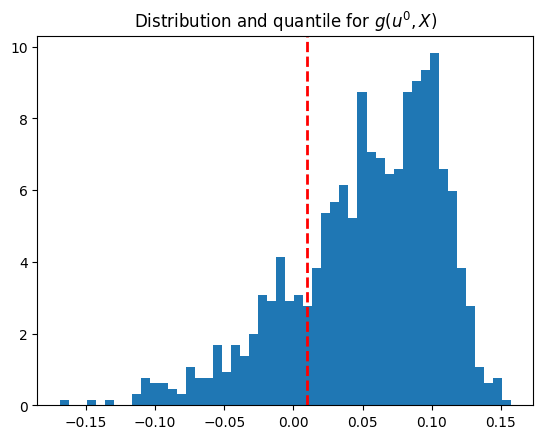

In [184]:
N_test = 1000
X_test = sample_from_X(size=N_test)
alpha = 0.2

# Histogram and quantiles for g_loc
Y_test = g_loc(X_test)
q_alpha = np.quantile(Y_test, alpha)

plt.figure()
plt.hist(Y_test, bins=50, density=True)
plt.axvline(x=q_alpha, linestyle='--', linewidth=2, color="red")
plt.title("Distribution and quantile for $g(u^0,X)$")
plt.show()



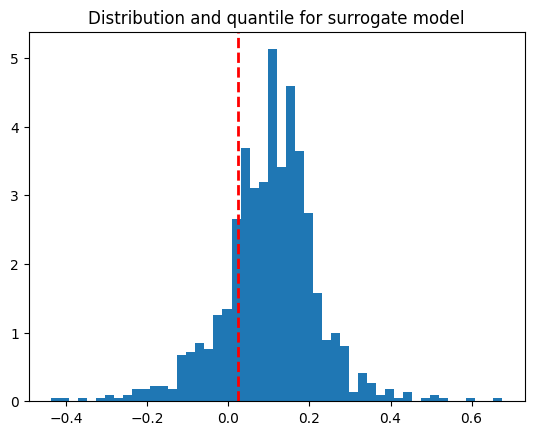

In [185]:
# Histogram and quantile for surrogate_g
u_test = np.repeat([[.5,.5]], N_test, axis=0) #u must be a 2d array, with the same number of rows as X
Y_test_surrogate = surrogate_g(u_test, X_test)
q_alpha_surrogate = np.quantile(Y_test_surrogate, alpha)

plt.figure()
plt.hist(Y_test_surrogate, bins=50, density=True)
plt.axvline(x=q_alpha_surrogate, linestyle='--', linewidth=2, color="red")
plt.title("Distribution and quantile for surrogate model")
plt.show()

## Step 4: optimization

You are now ready to solve the optimization problem by finding the point $u$ at which the quantile of order $0.2$ of $Y_u$ reaches its largest value!

**QUESTION:** implement the optimization method that seems the most relevant to you. Once you have found satisfactory values for $u_1$, $u_2$, [complete this form](https://forms.gle/sEcExqurFqNtukRB7) to send us your results.

In [187]:
import numpy as np

alpha = 0.2
N_mc = 1000

# Fixed MC sample (important for stability)
X_mc = sample_from_X(size=N_mc)

def evaluate_grid(U):
    """Vectorized evaluation of q_alpha over grid U"""
    U_rep = np.repeat(U, N_mc, axis=0)
    X_rep = np.tile(X_mc, (len(U), 1))

    Y = surrogate_g(U_rep, X_rep)
    Y = Y.reshape(len(U), N_mc)

    q_vals = np.quantile(Y, alpha, axis=1)
    return q_vals


best_u = np.array([0.0, 0.55])
best_q = -np.inf

target_precision = 1e-2


radius = 0.1

while radius > target_precision:

    # Define local bounds (stay in [0,1])
    u1_min = max(0, best_u[0] - radius)
    u1_max = min(1, best_u[0] + radius)
    u2_min = max(0, best_u[1] - radius)
    u2_max = min(1, best_u[1] + radius)

    # Local fine grid
    grid_size = 31
    u1_grid = np.linspace(u1_min, u1_max, grid_size)
    u2_grid = np.linspace(u2_min, u2_max, grid_size)

    U1, U2 = np.meshgrid(u1_grid, u2_grid)
    U = np.stack([U1.ravel(), U2.ravel()], axis=1)

    # Evaluate
    q_vals = evaluate_grid(U)

    # Update best
    best_idx = np.argmax(q_vals)
    best_u = U[best_idx]
    best_q = q_vals[best_idx]

    print(f"radius={radius:.4f} → best_u={best_u}, best_q={best_q}")

    # Shrink search window
    radius *= 0.5


print("best_u:", np.round(best_u, 2))  # .XX precision
print("best_q:", best_q)

radius=0.0125 → best_u=[0.         0.55833333], best_q=0.45836692041162536

✅ Final result:
best_u: [0.   0.56]
best_q: 0.45836692041162536
